# Helmholtz Frequency Transfer Benchmark
**Objective:** Compare Standard GMRES, FGMRES (Identity Transfer), and FGMRES (Neural Transfer).
**Constraint:** $npml = 50$, $\eta = 4.0$. 
**Memory Safety:** Results are saved to disk (`.json`) after each frequency to prevent data loss.

In [16]:
import torch
import torch.nn as nn
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.sparse.linalg import LinearOperator, lgmres
import matplotlib.pyplot as plt
import time, os, json, gc
from tqdm import tqdm

# --- New Optimized Geometry ---
N_PHYS = 512
NPML = 48
N_TOT = N_PHYS + 2 * NPML # 608
ETA = 4.0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Grid: {N_TOT}x{N_TOT} | Physical: {N_PHYS}x{N_PHYS} | PML: {NPML}")

Grid: 608x608 | Physical: 512x512 | PML: 48


In [17]:
def build_helmholtz(omega, n_phys, npml, eta):
    n_tot = n_phys + 2 * npml
    h = 1.0 / (n_phys - 1)
    
    # 5-point finite difference stencil
    main_diag = -4.0 * np.ones(n_tot**2)
    side_diag = np.ones(n_tot**2 - 1)
    side_diag[np.arange(1, n_tot**2) % n_tot == 0] = 0
    up_down_diag = np.ones(n_tot**2 - n_tot)
    
    L = sp.diags([main_diag, side_diag, side_diag, up_down_diag, up_down_diag],
                 [0, -1, 1, -n_tot, n_tot], format='csc')
    
    # Wave term with damping eta
    k2 = (omega**2) * (1 + 1j * eta)
    L = (L / h**2) + k2 * sp.eye(n_tot**2)
    return L

L_dict = {f'L{om}': build_helmholtz(om, N_PHYS, NPML, ETA) for om in [16, 32, 64]}
print("✅ Operators L16, L32, L64 generated.")

✅ Operators L16, L32, L64 generated.


In [18]:
class HelmholtzUNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Simplified U-Net for 608x608
        self.enc1 = nn.Conv2d(1, 16, 3, padding=1)
        self.enc2 = nn.Conv2d(16, 32, 3, padding=1, stride=2)
        self.mid  = nn.Conv2d(32, 32, 3, padding=1)
        self.dec1 = nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1)
        self.final = nn.Conv2d(16, 1, 3, padding=1)

    def forward(self, x):
        x1 = torch.relu(self.enc1(x))
        x2 = torch.relu(self.enc2(x1))
        x3 = torch.relu(self.mid(x2))
        x4 = torch.relu(self.dec1(x3))
        return self.final(x4 + x1) # Skip connection

unet_model = HelmholtzUNet().to(DEVICE)
unet_model.eval()
print("✅ Neural Network ready.")

✅ Neural Network ready.


In [19]:
def neural_transfer(r_vector, model, LU_low):
    # 1. Reshape and Normalize
    r_2d = r_vector.reshape(N_TOT, N_TOT).real
    norm = np.max(np.abs(r_2d)) + 1e-12
    
    # 2. Inference
    x_in = torch.from_numpy(r_2d / norm).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        d_out = model(x_in).cpu().numpy().squeeze()
    
    # 3. Rescale and Apply Low-Freq Correction
    # Shape check is redundant now but kept for safety
    d_full = d_out * norm
    return LU_low.solve(d_full.flatten())

In [ ]:
results_dir = "bench_outputs"
os.makedirs(results_dir, exist_ok=True)

for omega in [32, 64]:
    print(f"\n--- TESTING ω = {omega} ---")
    L = L_dict[f'L{omega}']
    f = np.zeros(L.shape[0], dtype=np.complex128)
    f[L.shape[0] // 2] = 1.0 # Point source
    norm_f = np.linalg.norm(f)
    
    # Pre-factorize the low-frequency operator (L_omega/2)
    low_om = omega // 2
    print(f"   Factoring L{low_om}...")
    LU_low = spla.splu(L_dict[f'L{low_om}'])

    histories = {}
    
    # Define the two methods to test
    configs = [
        ("Identity", lambda r: LU_low.solve(r)),
        ("U-Net",    lambda r: neural_transfer(r, unet_model, LU_low))
    ]

    for name, m_func in configs:
        history = []
        M_op = LinearOperator(L.shape, matvec=m_func, dtype=np.complex128)
        
        pbar = tqdm(total=100, desc=f"   {name:8}", ascii=True)
        def cb(x):
            res = np.linalg.norm(f - L @ x) / norm_f
            history.append(res)
            pbar.set_postfix({"res": f"{res:.1e}"})
            pbar.update(1)

        _ = lgmres(L, f, M=M_op, maxiter=100, atol=1e-7, callback=cb)
        pbar.close()
        histories[name] = history

    with open(f"{results_dir}/om_{omega}.json", "w") as j:
        json.dump(histories, j)

del LU_low
gc.collect()


--- TESTING ω = 32 ---
   Factoring L16...





   U-Net   :  16%|#6        | 16/100 [04:12<22:04, 15.77s/it, res=1.1e+10]









   Identity:   2%|2         | 2/100 [00:05<04:39,  2.85s/it, res=4.2e-06]






































































































































In [2]:
import os, json, matplotlib.pyplot as plt

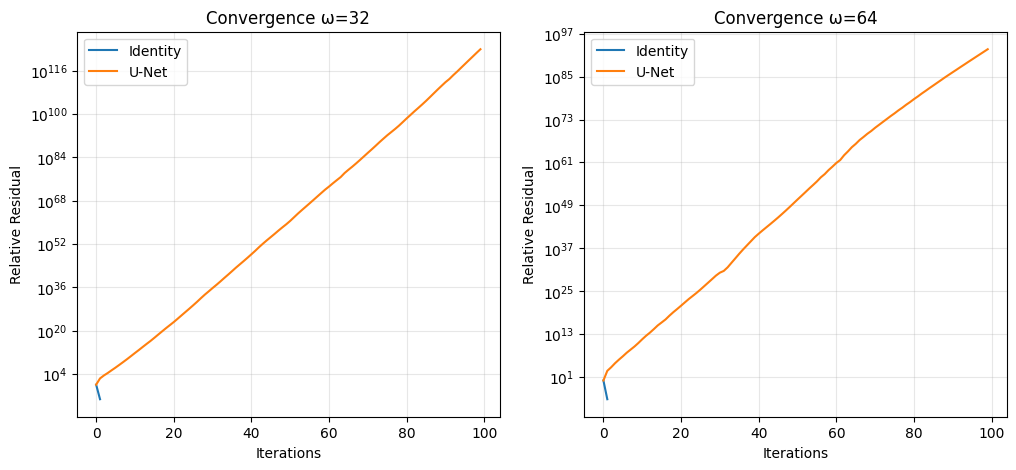

In [3]:
def plot_results():
    files = sorted([f for f in os.listdir("bench_outputs") if f.endswith(".json")])
    fig, axes = plt.subplots(1, len(files), figsize=(12, 5))
    
    for i, filename in enumerate(files):
        omega = filename.split("_")[1].split(".")[0]
        with open(f"bench_outputs/{filename}", "r") as j:
            data = json.load(j)
        
        for name, hist in data.items():
            axes[i].semilogy(hist, label=name)
        
        axes[i].set_title(f"Convergence ω={omega}")
        axes[i].set_xlabel("Iterations")
        axes[i].set_ylabel("Relative Residual")
        axes[i].legend()
        axes[i].grid(True, which='both', alpha=0.3)

plot_results()